In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils.transforms import normalize, unnormalize
from botorch.utils.sampling import draw_sobol_samples
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated     # ← Required import
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_default_dtype(torch.float64)

/home/mohamed/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ────────────────────────────────────────────────
#  Objective function
# ────────────────────────────────────────────────

def objective_function(x: torch.Tensor) -> torch.Tensor:
    """
    Input:  (n × 100) tensor in [0,1]^100
    Output: (n × 2) tensor of objectives to maximize
    """
    n, d = x.shape
    assert d == 100
    
    half = d // 2
    m1 = x[:, :half].mean(dim=1)
    m2 = x[:, half:].mean(dim=1)
    
    angle = 2.0 * np.pi * m2
    obj1 = m1 * torch.cos(angle)
    obj2 = m1 * torch.sin(angle)
    
    return -torch.stack([obj1, obj2], dim=-1)


dim = 100
bounds = torch.stack([torch.zeros(dim), torch.ones(dim)])

n_init = 128
batch_size = 4
n_iterations = 20

length_init = 0.8
length_min  = 0.01
length_max  = 1.6

In [3]:
# ────────────────────────────────────────────────
#  Initial design
# ────────────────────────────────────────────────

X = draw_sobol_samples(bounds, n=1, q=n_init).squeeze(0)
Y = objective_function(X)

hv_history = []
pareto_history = []           # list of Pareto front tensors per iteration

print(f"Initial design generated: {X.shape[0]} points")

# Initial Pareto front
nadir_init = Y.min(dim=0).values
ref_init = nadir_init - 0.1 * (Y.max(dim=0).values - nadir_init)
initial_mask = is_non_dominated(Y)          # ← corrected
pareto_history.append(Y[initial_mask].clone())

Initial design generated: 128 points


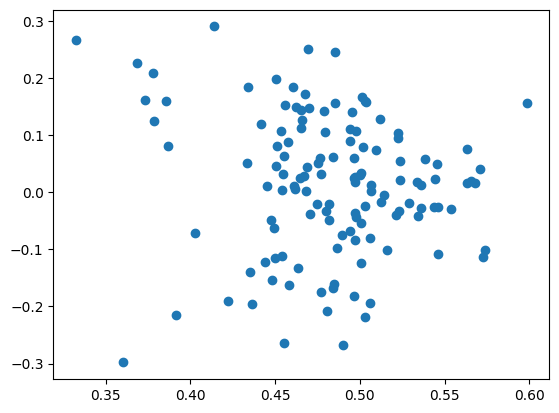

In [4]:
plt.scatter(Y[:, 0], Y[:, 1])

In [5]:
# ────────────────────────────────────────────────
#  Optimization loop
# ────────────────────────────────────────────────

current_center = X.mean(dim=0)
current_length = torch.tensor(length_init, dtype=torch.float64)

for it in range(n_iterations):
    tr_lower = current_center - current_length / 2
    tr_upper = current_center + current_length / 2
    tr_bounds = torch.stack([tr_lower.clamp(min=0.0), tr_upper.clamp(max=1.0)])
    
    X_norm = normalize(X, tr_bounds)
    X_norm = torch.clamp(X_norm, min=0.0, max=1.0)
    
    gp = SingleTaskGP(X_norm, Y)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    
    nadir = Y.min(dim=0).values
    ref_point = nadir - 0.1 * (Y.max(dim=0).values - nadir)
    
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([128]))
    
    acqf = qLogNoisyExpectedHypervolumeImprovement(
        model=gp,
        ref_point=ref_point,
        X_baseline=X_norm,
        sampler=sampler,
        prune_baseline=True,
    )
    
    candidates_norm, _ = optimize_acqf(
        acq_function=acqf,
        bounds=torch.stack([torch.zeros(dim), torch.ones(dim)]),
        q=batch_size,
        num_restarts=8,
        raw_samples=256,
        options={"batch_limit": 5, "maxiter": 100},
    )
    
    X_new = unnormalize(candidates_norm, tr_bounds)
    Y_new = objective_function(X_new)
    
    X = torch.cat([X, X_new], dim=0)
    Y = torch.cat([Y, Y_new], dim=0)
     
    # Trust region update
    max_prev = Y[:-batch_size].max(dim=0).values
    max_new  = Y_new.max(dim=0).values
    improvement = (max_new - max_prev).max().item()
    
    if improvement > 0:
        current_length = min(length_max, current_length * 1.5)
        current_center = 0.7 * current_center + 0.3 * X_new.mean(dim=0)
        print(f"Iter {it+1:3d} | TR length {current_length:.4f} | Improvement")
    else:
        current_length = max(length_min, current_length * 0.7)
        print(f"Iter {it+1:3d} | TR length {current_length:.4f}")
    
    # Hypervolume
    partitioning = FastNondominatedPartitioning(ref_point=ref_point, Y=Y)
    hv = partitioning.compute_hypervolume().item()
    hv_history.append(hv)
    print(f"   Hypervolume = {hv:.4e}")
    
    # Pareto-optimal solutions history
    current_mask = is_non_dominated(Y)          # ← corrected
    current_pareto = Y[current_mask].clone()
    pareto_history.append(current_pareto)
    print(f"   Pareto front size: {len(current_pareto)} points")

Iter   1 | TR length 1.2000 | Improvement
   Hypervolume = 2.2398e-01
   Pareto front size: 6 points
Iter   2 | TR length 1.6000 | Improvement
   Hypervolume = 1.3657e+00
   Pareto front size: 3 points
Iter   3 | TR length 1.6000 | Improvement
   Hypervolume = 1.5644e+00
   Pareto front size: 4 points
Iter   4 | TR length 1.6000 | Improvement
   Hypervolume = 1.6969e+00
   Pareto front size: 6 points
Iter   5 | TR length 1.6000 | Improvement
   Hypervolume = 1.7555e+00
   Pareto front size: 6 points
Iter   6 | TR length 1.1200
   Hypervolume = 1.7762e+00
   Pareto front size: 6 points
Iter   7 | TR length 0.7840
   Hypervolume = 1.8217e+00
   Pareto front size: 6 points
Iter   8 | TR length 0.5488
   Hypervolume = 1.8288e+00
   Pareto front size: 6 points
Iter   9 | TR length 0.8232 | Improvement
   Hypervolume = 1.8583e+00
   Pareto front size: 7 points
Iter  10 | TR length 0.5762
   Hypervolume = 1.8658e+00
   Pareto front size: 7 points
Iter  11 | TR length 0.4034
   Hypervolume = 1

In [6]:
# ────────────────────────────────────────────────
#  Final results + Pareto history summary
# ────────────────────────────────────────────────

nadir_final = Y.min(dim=0).values
ref_final = nadir_final - 0.1 * (Y.max(dim=0).values - nadir_final)
final_mask = is_non_dominated(Y)                    # ← corrected
pareto_Y_final = Y[final_mask]

print("\nFinal approximate Pareto front (showing up to 15 points):")
print(pareto_Y_final[:15] if len(pareto_Y_final) > 0 else "No non-dominated points found.")

print(f"\nMaximum hypervolume achieved: {hv_history[-1]:.4e}")
print(f"Final Pareto front size: {len(pareto_Y_final)} points")

# Pareto history summary
print("\nPareto front evolution summary:")
for i, front in enumerate(pareto_history):
    label = "Initial" if i == 0 else f"After iter {i}"
    hv_val = "N/A" if i == 0 else f"{hv_history[i-1]:.4e}"
    print(f"  {label:12s} | {len(front):3d} points | HV = {hv_val}") 


Final approximate Pareto front (showing up to 15 points):
tensor([[ 0.4175,  0.8321],
        [-0.0685,  0.9433],
        [ 0.8489,  0.4414],
        [ 0.1545,  0.9305],
        [ 0.6720,  0.6639],
        [ 0.7191,  0.5921],
        [ 0.9037,  0.1165],
        [ 0.7655,  0.5641],
        [ 0.4567,  0.6656]])

Maximum hypervolume achieved: 1.8716e+00
Final Pareto front size: 9 points

Pareto front evolution summary:
  Initial      |   7 points | HV = N/A
  After iter 1 |   6 points | HV = 2.2398e-01
  After iter 2 |   3 points | HV = 1.3657e+00
  After iter 3 |   4 points | HV = 1.5644e+00
  After iter 4 |   6 points | HV = 1.6969e+00
  After iter 5 |   6 points | HV = 1.7555e+00
  After iter 6 |   6 points | HV = 1.7762e+00
  After iter 7 |   6 points | HV = 1.8217e+00
  After iter 8 |   6 points | HV = 1.8288e+00
  After iter 9 |   7 points | HV = 1.8583e+00
  After iter 10 |   7 points | HV = 1.8658e+00
  After iter 11 |   8 points | HV = 1.8715e+00
  After iter 12 |   8 points | H

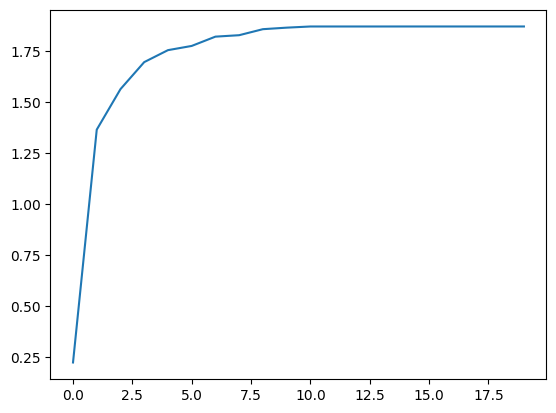

In [7]:
plt.plot(hv_history)

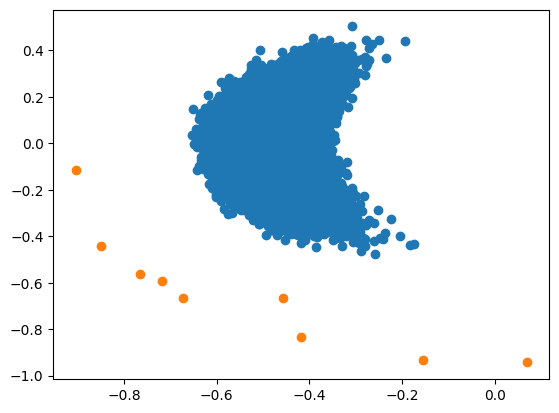

In [8]:
def objective_function(x):
    return np.array([np.mean(x[:len(x) // 2])*np.cos(2*np.pi*np.mean(x[len(x) // 2:])), 
                     np.mean(x[:len(x) // 2])*np.sin(2*np.pi*np.mean(x[len(x) // 2:]))])

S = [np.random.uniform(0, 1, 100) for _ in range(100000)]
data = np.array([objective_function(x) for x in S])
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(-pareto_history[-1][:, 0], -pareto_history[-1][:, 1])